# Agentic AI for Airline Hub Disruption Management

## Introduction

Scandinavian Airlines (SAS) announced plans to deploy AI systems at its Copenhagen and Stockholm hubs by 2026. The goal is to reduce flight disruptions caused by weather, technical issues, and airspace congestion [1]. The system will process real-time data on aircraft positions, crew availability, and weather so dispatchers can make faster, data-driven decisions during irregular operations.

Disruption management is one of the hardest problems in airline operations. A single storm at a hub airport can cascade into dozens of delayed or cancelled flights, strand thousands of passengers, and push crew members past their legal duty-time limits. Today, human dispatchers in operations control centers (OCC) coordinate these decisions manually under extreme time pressure. Airlines like SAS are betting that AI can help.

In this notebook, we build a local multi-agent AI system that simulates how an airline OCC might handle a storm disruption at a Copenhagen-like hub. Three specialized AI agents collaborate to analyze a disrupted schedule, check crew constraints, and produce a concrete action plan. The entire system runs on a Mac with M-series chip and 8 GB of RAM using a small language model served locally by Ollama.

## Environment Setup

This demo runs on a Mac with M-series chip and 8 GB of RAM. All AI inference happens locally using Ollama.

**Prerequisites:**
- Install [Miniconda](https://www.anaconda.com/docs/getting-started/miniconda/install)
- Install [Ollama](https://ollama.com/) and pull the `llama3.2:3b` model

**Terminal commands to set up the environment:**
```bash
# Create and activate the conda environment
conda create -n ops-control python=3.10 -y
conda activate ops-control

# Install core libraries via conda
conda install -c conda-forge pandas jupyter ipykernel ipython pillow matplotlib seaborn -y

# Install AI/agent libraries and pymupdf via pip
pip install pymupdf crewai crewai-tools langchain-ollama

# Register the kernel
python -m ipykernel install --user --name ops-control --display-name "Python (ops-control)"

# Pull the LLM model
ollama pull llama3.2:3b

# Clear cache
conda clean -a -y && pip cache purge
```

In [32]:
import pandas as pd
import sqlite3
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
from crewai import Agent, Task, Crew, Process, LLM
from crewai.tools import tool

In [33]:
import pymupdf as fitz
from IPython.display import Image as IPythonImage, display, SVG

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.precision', 2)

def show_image(image_path, width=500, page_num=0, dpi=300):
    if image_path.lower().endswith('.pdf'):
        doc = fitz.open(image_path)
        page = doc.load_page(page_num)
        pix = page.get_pixmap(dpi=dpi)
        img_data = pix.tobytes("png")
        doc.close()
        display(IPythonImage(data=img_data, width=width))
    elif image_path.lower().endswith('.svg'):
        display(SVG(image_path))
    else:
        display(IPythonImage(filename=image_path, width=width))

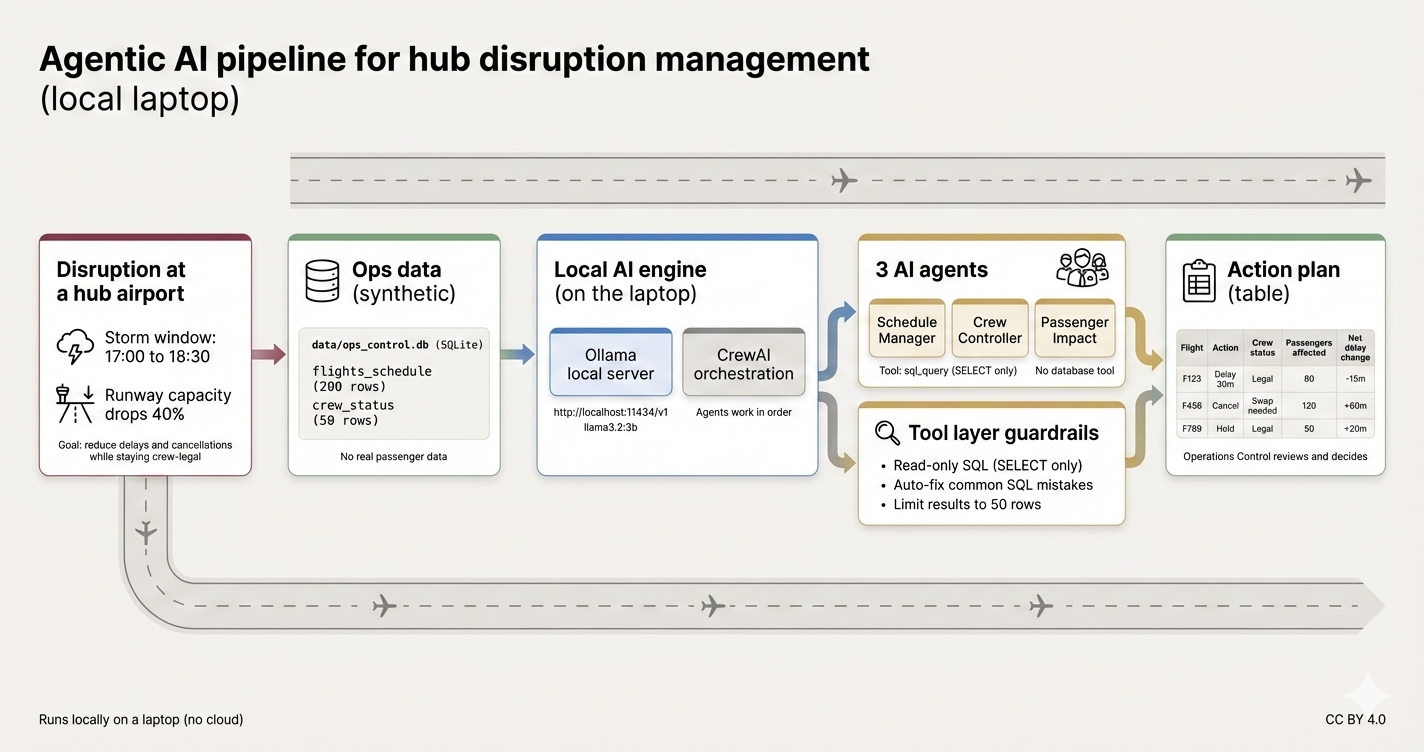

In [37]:
show_image('assets/pipeline-dev.png', width=800)

Figure: A local multi-agent AI setup can support hub disruption decisions by querying an operations database, checking crew constraints, and producing a simple action plan table for the Operations Control Center.

## What is Agentic AI and Multi-Agent Systems?

Traditional AI models work like calculators: you give them an input, they produce an output, and that is it. **Agentic AI** is different. You give an AI agent a *goal* and a set of *tools*, and it decides on its own what steps to take. It can query databases, run calculations, and reason through options, much like a human expert working through a problem.

Think of it this way. If a regular AI model is like a vending machine (press a button, get a fixed result), an agentic AI is more like a new employee given a task and access to the company's systems. The employee figures out which systems to check, what questions to ask, and how to piece together an answer.

A **multi-agent system** takes this further by having multiple specialized agents work together. Each agent has its own role, goal, and tools. They pass information between each other and build on each other's work.

**AI Agents vs. Agentic AI.** These two terms are often used interchangeably, but they refer to different things [5][6]. An **AI Agent** is a single system that performs a specific task by using tools, applying chain-of-thought reasoning, and responding to changes on its own. Think of it as one specialist employee who is good at one job. **Agentic AI**, on the other hand, is a system of multiple AI agents that coordinate, communicate, and divide work among themselves to achieve a larger goal. It is the difference between hiring one expert versus assembling a team where each member has a different specialty. In our airline demo, each of the three agents below is an *AI Agent*; the whole crew working together is an *Agentic AI* system.

This maps directly to how airline operations control centers work in practice:

| OCC Role | AI Agent | Responsibility |
|---|---|---|
| Schedule Coordinator | Schedule Manager Agent | Adjusts the flight schedule (delays, cancellations, gate swaps) to minimize total disruption |
| Crew Scheduler | Crew Controller Agent | Checks that no crew member exceeds legal duty-time limits and proposes reassignments when needed |
| Passenger Services | Passenger Impact Agent | Estimates how many passengers will misconnect and recommends rebooking actions |

In a real OCC, these three desks constantly talk to each other. The schedule coordinator might propose cancelling a flight, the crew scheduler confirms whether replacement crew is available, and passenger services estimates how many travelers are affected. Our AI agents will follow the same collaborative pattern.

**How agents reason and act.** Under the hood, each agent follows a loop called ReAct (Reasoning + Acting). In each step, the agent:

1. **Thinks** about what it knows so far and what it still needs.
2. **Acts** by calling a tool (e.g., running a SQL query against the operations database).
3. **Observes** the result and decides whether to take another action or deliver a final answer.

This loop repeats until the agent has enough information to complete its task. The language model powering each agent generates both the reasoning and the tool calls as text, which the framework (CrewAI) parses and executes [2].

**CrewAI** is the orchestration framework we use. It lets us define agents, assign them tools, and organize them into a "crew" that executes tasks in sequence. Agent A finishes its analysis, then Agent B picks up from there and adds its own perspective [2]. **Ollama** serves the language model locally on our laptop, so no data leaves the machine [3].

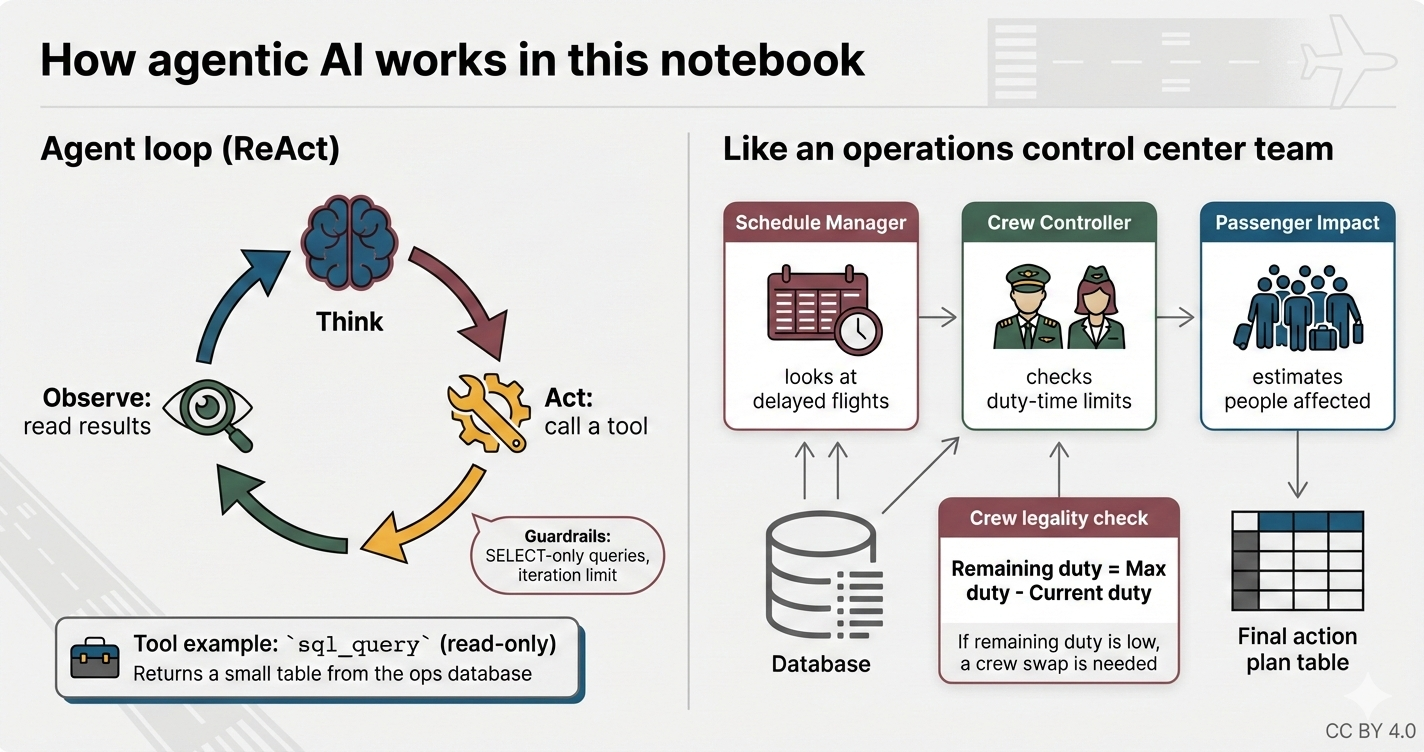

In [38]:
show_image('assets/aitheory-dev.png', width=800)

Figure: Agentic AI works as a loop where the model thinks, calls tools like a read-only SQL query, and uses the results to decide the next step. With multiple agents, each role focuses on one part of the disruption problem and hands off to the next, similar to how an airline operations control center team works.

## Dataset

We create a synthetic SQLite database (`ops_control.db`) that represents a snapshot of hub operations at Copenhagen Airport (CPH) on a busy afternoon. The database contains two tables:

**`flights_schedule`** (~200 rows) stores the flight schedule with columns for flight ID, origin, destination, scheduled departure and arrival times, current delay in minutes, assigned aircraft, assigned captain and first officer, seat capacity, booked passengers, and gate assignment. Every flight requires both a qualified captain and a qualified first officer in the cockpit. The scenario is set around a late-afternoon storm expected between 17:00 and 18:30 local time that will reduce runway throughput by roughly 40%. Several inbound flights are already showing delays of 20 to 60 minutes.

**`crew_status`** (~50 rows) tracks each crew member's role (captain or first officer), current duty hours, maximum allowed duty hours, base airport, and the aircraft types they are qualified to operate. The roster includes 20 captains and 30 first officers, reflecting the higher qualification requirements for the captain position. European regulations (EU-OPS FTL) cap a crew member's single duty period at around 13 hours, depending on the start time and number of sectors [4]. Crews approaching their limits cannot be reassigned to longer duties without a rest break.

The agents will query this database using SQL during their reasoning process, just as real OCC staff query their operational systems.

> **DISCLAIMER**: All data in this notebook is **synthetic and hypothetical**. Aircraft specifications, route information, and performance metrics are rough estimates based on publicly available industry benchmarks. This data does not represent actual airline operational data. This demonstration is for educational purposes only to illustrate AI concepts.

## Data Preparation

We start by creating a SQLite database file at `data/ops_control.db`. If a previous version exists, we remove it and build fresh. The database will hold two tables: `flights_schedule` and `crew_status`.

In [4]:
import random

DB_PATH = "data/ops_control.db"

# Remove old database if it exists
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

### Flights Schedule Table

The `flights_schedule` table captures a snapshot of flights at Copenhagen Airport. We model a mix of departures and arrivals across European destinations. Each flight is assigned both a captain and a first officer from the crew roster. The storm window (17:00-18:30) means flights scheduled in that period will have higher delays. We use a fixed random seed so results are reproducible.

In [5]:
cursor.execute("""
    CREATE TABLE flights_schedule (
        flight_id TEXT PRIMARY KEY,
        origin TEXT,
        destination TEXT,
        scheduled_dep TEXT,
        scheduled_arr TEXT,
        current_delay_min INTEGER,
        aircraft_id TEXT,
        captain_id TEXT,
        first_officer_id TEXT,
        seats_total INTEGER,
        seats_booked INTEGER,
        gate TEXT
    )
""")
conn.commit()

In [6]:
random.seed(42)

# --- Airport and route configuration ---
airports = {
    "ARN": "Stockholm",
    "OSL": "Oslo",
    "HEL": "Helsinki",
    "FRA": "Frankfurt",
    "LHR": "London Heathrow",
    "AMS": "Amsterdam",
    "CDG": "Paris CDG",
    "MUC": "Munich",
    "ZRH": "Zurich",
    "BRU": "Brussels",
    "WAW": "Warsaw",
    "VIE": "Vienna",
    "BCN": "Barcelona",
    "FCO": "Rome",
    "ATH": "Athens",
    "BER": "Berlin",
    "DUB": "Dublin",
    "LIS": "Lisbon",
    "GOT": "Gothenburg",
    "BLL": "Billund",
}

# Aircraft types with seat capacities (narrowbody fleet typical of SAS)
aircraft_types = {
    "A320": {"seats_range": (150, 180), "prefix": "A32"},
    "A321": {"seats_range": (185, 220), "prefix": "A21"},
    "A319": {"seats_range": (120, 144), "prefix": "A19"},
    "B737": {"seats_range": (149, 189), "prefix": "B73"},
    "CRJ9": {"seats_range": (76, 90), "prefix": "CR9"},
    "E195": {"seats_range": (100, 132), "prefix": "E95"},
}

# Gate assignments at CPH
gates = [f"A{i}" for i in range(1, 16)] + [f"B{i}" for i in range(1, 21)] + [f"C{i}" for i in range(1, 11)]

# Flight time windows (hour ranges for scheduled departures/arrivals)
dep_hours = list(range(6, 23))  # 06:00 to 22:00

# Storm window: 17:00 - 18:30
STORM_START = 17.0
STORM_END = 18.5

In [7]:
def generate_flights(n_flights=200):
    """Generate synthetic flight schedule data for CPH hub."""
    flights = []
    airport_codes = list(airports.keys())
    ac_type_list = list(aircraft_types.keys())
    
    # Create a pool of aircraft (42 aircraft)
    aircraft_pool = []
    for ac_type in ac_type_list:
        info = aircraft_types[ac_type]
        for i in range(1, 8):
            aircraft_pool.append({
                "aircraft_id": f"{info['prefix']}-{i:03d}",
                "type": ac_type,
                "seats_total": random.randint(*info["seats_range"]),
            })
    
    # Separate crew pools: 20 captains (CRW-001 to CRW-020), 30 first officers (CRW-021 to CRW-050)
    captain_ids = [f"CRW-{i:03d}" for i in range(1, 21)]
    fo_ids = [f"CRW-{i:03d}" for i in range(21, 51)]
    
    used_flight_ids = set()
    
    for i in range(n_flights):
        # Ensure unique flight IDs
        while True:
            flight_num = f"SK{random.randint(100, 999)}{chr(65 + i % 26)}"
            if flight_num not in used_flight_ids:
                used_flight_ids.add(flight_num)
                break
        
        # Half departures from CPH, half arrivals to CPH
        if i % 2 == 0:
            origin = "CPH"
            destination = random.choice(airport_codes)
        else:
            origin = random.choice(airport_codes)
            destination = "CPH"
        
        # Schedule times
        dep_hour = random.choice(dep_hours)
        dep_min = random.choice([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55])
        scheduled_dep = f"{dep_hour:02d}:{dep_min:02d}"
        
        # Flight duration: 1-4 hours depending on route
        flight_duration_min = random.randint(60, 240)
        arr_hour = dep_hour + flight_duration_min // 60
        arr_min = dep_min + flight_duration_min % 60
        if arr_min >= 60:
            arr_hour += 1
            arr_min -= 60
        arr_hour = min(arr_hour, 23)
        scheduled_arr = f"{arr_hour:02d}:{arr_min:02d}"
        
        # Assign aircraft and crew (each flight needs both a captain and a first officer)
        aircraft = random.choice(aircraft_pool)
        captain_id = random.choice(captain_ids)
        fo_id = random.choice(fo_ids)
        
        # Determine delay based on proximity to storm window
        dep_decimal = dep_hour + dep_min / 60.0
        if STORM_START <= dep_decimal <= STORM_END:
            # Flights during storm: higher delays (20-60 min)
            current_delay = random.randint(20, 60)
        elif STORM_START - 1.0 <= dep_decimal < STORM_START:
            # Flights just before storm: moderate delays (10-35 min)
            current_delay = random.choice([0, 0, 10, 15, 20, 25, 35])
        elif STORM_END < dep_decimal <= STORM_END + 1.0:
            # Flights just after storm: residual delays
            current_delay = random.choice([0, 0, 0, 10, 15, 20, 30])
        else:
            # Normal operations: mostly on time
            current_delay = random.choice([0, 0, 0, 0, 0, 0, 5, 10, 15])
        
        seats_total = aircraft["seats_total"]
        load_factor = random.uniform(0.55, 0.95)
        seats_booked = int(seats_total * load_factor)
        
        gate = random.choice(gates)
        
        flights.append((
            flight_num, origin, destination, scheduled_dep, scheduled_arr,
            current_delay, aircraft["aircraft_id"], captain_id, fo_id,
            seats_total, seats_booked, gate
        ))
    
    return flights

flights_data = generate_flights(200)
cursor.executemany(
    "INSERT INTO flights_schedule VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)",
    flights_data
)
conn.commit()
print(f"Inserted {len(flights_data)} rows into flights_schedule")

Inserted 200 rows into flights_schedule


### Crew Status Table

The `crew_status` table tracks each crew member's role, duty hours, and qualifications. There are two roles: **captain** and **first officer**. The roster has 20 captains and 30 first officers. Captains are fewer because the position requires a higher level of training, flight hours, and type rating certifications. European regulations (EU-OPS FTL) cap a single duty period at around 13 hours depending on start time and number of sectors [4]. Crews near their limit become a constraint when the schedule needs to change. Each crew member is qualified for one or more aircraft types.

In [8]:
cursor.execute("""
    CREATE TABLE crew_status (
        crew_id TEXT PRIMARY KEY,
        role TEXT,
        current_duty_hours REAL,
        max_duty_hours REAL,
        base_airport TEXT,
        qualified_aircraft_types TEXT
    )
""")

# Base airports for crews
crew_bases = ["CPH", "CPH", "CPH", "CPH", "ARN", "ARN", "OSL"]
ac_type_names = list(aircraft_types.keys())

crew_data = []
for i in range(1, 51):
    crew_id = f"CRW-{i:03d}"
    
    # First 20 are captains, remaining 30 are first officers
    role = "captain" if i <= 20 else "first_officer"
    
    # Max duty hours: 11-13 hours per EU-OPS FTL
    max_duty = round(random.uniform(11.0, 13.0), 1)
    
    # Current duty hours: some crews are fresh, some near their limit
    # Afternoon scenario: crews have been working 2-11 hours already
    current_duty = round(random.uniform(2.0, 11.0), 1)
    
    # Ensure current does not exceed max
    current_duty = min(current_duty, max_duty - 0.5)
    
    base = random.choice(crew_bases)
    
    # Each crew is qualified for 1-3 aircraft types
    # Captains tend to have fewer type ratings (1-2) due to stricter requirements
    if role == "captain":
        n_qualified = random.randint(1, 2)
    else:
        n_qualified = random.randint(1, 3)
    qualified = ", ".join(random.sample(ac_type_names, n_qualified))
    
    crew_data.append((crew_id, role, current_duty, max_duty, base, qualified))

cursor.executemany(
    "INSERT INTO crew_status VALUES (?, ?, ?, ?, ?, ?)",
    crew_data
)
conn.commit()
print(f"Inserted {len(crew_data)} rows into crew_status")

Inserted 50 rows into crew_status


In [9]:
conn.close()
print("Database connection closed. Data preparation complete.")

Database connection closed. Data preparation complete.


### Sample Data

Let us inspect a few rows from each table to verify the data looks reasonable.

In [10]:
conn = sqlite3.connect(DB_PATH)

df_flights = pd.read_sql_query("SELECT * FROM flights_schedule", conn)
print(f"flights_schedule: {len(df_flights)} rows, {len(df_flights.columns)} columns\n")
df_flights.head(10)

flights_schedule: 200 rows, 12 columns



,flight_id,origin,destination,scheduled_dep,scheduled_arr,current_delay_min,aircraft_id,captain_id,first_officer_id,seats_total,seats_booked,gate
0,SK194A,CPH,BCN,09:25,11:53,0,E95-004,CRW-009,CRW-046,109,91,B20
1,SK227B,BCN,CPH,08:40,10:55,0,E95-006,CRW-020,CRW-049,121,94,A5
2,SK146C,CPH,MUC,15:05,17:04,10,A32-007,CRW-013,CRW-029,157,126,B9
3,SK266D,VIE,CPH,17:15,21:06,60,A19-004,CRW-003,CRW-040,136,84,B1
4,SK267E,CPH,ATH,18:20,22:03,40,E95-001,CRW-008,CRW-042,127,112,A4
5,SK334F,OSL,CPH,16:30,18:38,20,A32-005,CRW-007,CRW-050,158,142,B6
6,SK317G,CPH,BER,18:50,21:47,0,A21-003,CRW-009,CRW-025,219,185,B20
7,SK369H,GOT,CPH,19:45,22:27,15,B73-003,CRW-008,CRW-025,175,130,A4
8,SK981I,CPH,FRA,10:50,12:30,5,B73-007,CRW-020,CRW-023,166,116,B15
9,SK641J,ZRH,CPH,06:50,08:19,0,CR9-007,CRW-009,CRW-045,87,51,B13


In [11]:
df_crew = pd.read_sql_query("SELECT * FROM crew_status", conn)
print(f"crew_status: {len(df_crew)} rows, {len(df_crew.columns)} columns\n")
df_crew.head(10)

crew_status: 50 rows, 6 columns



,crew_id,role,current_duty_hours,max_duty_hours,base_airport,qualified_aircraft_types
0,CRW-001,captain,9.2,11.8,CPH,"A321, E195"
1,CRW-002,captain,5.6,12.2,CPH,A320
2,CRW-003,captain,5.0,11.3,CPH,"A321, CRJ9"
3,CRW-004,captain,3.3,12.8,ARN,"A321, B737"
4,CRW-005,captain,8.7,13.0,CPH,"CRJ9, E195"
5,CRW-006,captain,8.4,12.1,CPH,"A320, A319"
6,CRW-007,captain,3.0,11.7,CPH,"E195, A320"
7,CRW-008,captain,4.4,12.2,ARN,E195
8,CRW-009,captain,6.3,11.1,ARN,"A321, E195"
9,CRW-010,captain,10.5,11.1,CPH,A320


In [12]:
# Summary statistics
delayed_flights = df_flights[df_flights["current_delay_min"] > 0]
storm_flights = df_flights[
    (df_flights["scheduled_dep"] >= "17:00") & (df_flights["scheduled_dep"] <= "18:30")
]
crews_near_limit = df_crew[
    (df_crew["max_duty_hours"] - df_crew["current_duty_hours"]) < 2.0
]
captains = df_crew[df_crew["role"] == "captain"]
first_officers = df_crew[df_crew["role"] == "first_officer"]
captains_near_limit = crews_near_limit[crews_near_limit["role"] == "captain"]
fo_near_limit = crews_near_limit[crews_near_limit["role"] == "first_officer"]

print("DATASET SUMMARY")
print(f"Total flights:             {len(df_flights)}")
print(f"Delayed flights:           {len(delayed_flights)} ({len(delayed_flights)/len(df_flights)*100:.0f}%)")
print(f"Flights in storm window:   {len(storm_flights)}")
print(f"Average delay (all):       {df_flights['current_delay_min'].mean():.1f} min")
print(f"Average delay (delayed):   {delayed_flights['current_delay_min'].mean():.1f} min")
print(f"Max delay:                 {df_flights['current_delay_min'].max()} min")
print(f"Total crew:                {len(df_crew)} (captains: {len(captains)}, first officers: {len(first_officers)})")
print(f"Crews near duty limit:     {len(crews_near_limit)} (< 2 hrs remaining)")
print(f"  Captains near limit:     {len(captains_near_limit)}")
print(f"  First officers near limit: {len(fo_near_limit)}")

DATASET SUMMARY
Total flights:             200
Delayed flights:           90 (45%)
Flights in storm window:   22
Average delay (all):       8.4 min
Average delay (delayed):   18.8 min
Max delay:                 60 min
Total crew:                50 (captains: 20, first officers: 30)
Crews near duty limit:     9 (< 2 hrs remaining)
  Captains near limit:     3
  First officers near limit: 6


In [27]:
# Clean up temporary variables from data preparation
_cleanup_vars = [
    'df_flights', 'df_crew', 'delayed_flights', 'storm_flights',
    'crews_near_limit', 'flights_data', 'crew_data', 'airports',
    'aircraft_types', 'gates', 'dep_hours', 'ac_type_list',
    'ac_type_names', 'crew_bases', 'generate_flights',
    'captains', 'first_officers', 'captains_near_limit', 'fo_near_limit',
    'i', 'crew_id', 'role', 'max_duty', 'current_duty', 'base',
    'n_qualified', 'qualified', 'cursor', 'random',
]
for _v in _cleanup_vars:
    if _v in dir():
        exec(f"del {_v}")
del _cleanup_vars, _v

try:
    conn.close()
except Exception:
    pass

import gc
gc.collect()
print("Temporary data preparation variables cleaned up.")

Temporary data preparation variables cleaned up.


### Data Observations

The synthetic database contains **200 flights** and **50 crew members** (20 captains, 30 first officers) at the CPH hub. About 45% of flights show some delay, with 22 flights falling inside the storm window (17:00-18:30). The average delay across delayed flights is around 19 minutes, with a maximum of 60 minutes. Nine crew members have fewer than 2 hours of duty time remaining (3 captains, 6 first officers), which limits the options for schedule changes involving those crews. Since every flight needs both a qualified captain and a qualified first officer, the smaller captain pool makes captain availability the tighter constraint during disruptions.

This represents a realistic stress scenario for an operations control center. The agents will query this database directly using SQL as they reason through their disruption response plan.

## Agent Definitions and Crew Setup

### Language Model Configuration

We use Ollama to serve the LLM locally. Ollama runs a local HTTP server on `localhost:11434` and handles all inference on-device using the Apple M-series GPU (Metal). No data leaves the machine.

We use **Llama 3.2 3B** (3 billion parameters) from Meta [9]. At this size, it fits comfortably in 8 GB of RAM and supports native tool calling, which is important for our agents to query the database. The smaller parameter count also means faster inference, which keeps the multi-agent workflow within our time budget. We set `temperature=0.2` to make the output more deterministic and focused, which is important for operational decision-making where we want consistent, repeatable recommendations rather than creative text.

CrewAI (v1.9) includes a built-in `LLM` class that connects to various model providers. Since Ollama exposes an OpenAI-compatible API at `http://localhost:11434/v1`, we point CrewAI's LLM to that endpoint. This avoids the need for any cloud API keys.

In [14]:
llm = LLM(
    model="llama3.2:3b",
    base_url="http://localhost:11434/v1",
    api_key="ollama",
    temperature=0.2,
)
print(f"LLM configured: {llm.model}")
print(f"Temperature: {llm.temperature}")

LLM configured: llama3.2:3b
Temperature: 0.2


### SQL Query Tool

AI agents need tools to interact with the outside world. In our case, the agents need to query the SQLite database to look up flight schedules, crew duty hours, and passenger counts. We define a single reusable SQL tool using CrewAI's `@tool` decorator.

The tool takes a raw SQL query string, executes it against our `ops_control.db` database, and returns the results as a formatted string. We restrict the tool to `SELECT` statements only as a safety measure. This prevents the agents from accidentally modifying the data while reasoning through the problem. We also limit results to 50 rows to keep the LLM's context window from overflowing with large result sets.

In [15]:
import re as _re

def _fix_unquoted_times(query: str) -> str:
    """Wrap bare HH:MM time literals in single quotes so SQLite can parse them."""
    pattern = r"(?<!['\"\w])(\d{1,2}:\d{2}(?::\d{2})?)(?!['\"\w])"
    return _re.sub(pattern, r"'\1'", query)


def _fix_incomplete_between(query: str) -> str:
    """Repair incomplete BETWEEN clauses with default storm-window times."""
    return _re.sub(
        r"BETWEEN\s*(?=LIMIT|ORDER|GROUP|$)",
        "BETWEEN '17:00' AND '18:30' ",
        query,
        flags=_re.IGNORECASE,
    )


def _fix_alias_in_order_by(query: str) -> str:
    """Fix table-qualified references to SELECT aliases in ORDER BY.
    Replaces table.alias with just alias when alias is defined via AS."""
    aliases = set(_re.findall(r'\bAS\s+(\w+)', query, _re.IGNORECASE))
    if not aliases:
        return query
    for alias in aliases:
        pattern = r'\b\w+\.' + _re.escape(alias) + r'\b'
        query = _re.sub(pattern, alias, query)
    return query


def _fix_group_by_without_aggregates(query: str) -> str:
    """Remove GROUP BY when query has no aggregate functions."""
    upper = query.upper()
    if "GROUP BY" in upper and not _re.search(
        r'\b(COUNT|SUM|AVG|MIN|MAX|GROUP_CONCAT)\s*\(', upper
    ):
        query = _re.sub(
            r'\s+GROUP\s+BY\s+[^)]+?(?=\s+ORDER|\s+LIMIT|\s+HAVING|\s*$)',
            ' ',
            query,
            flags=_re.IGNORECASE,
        )
    return query


def _fix_unquoted_ids_in_clause(query: str) -> str:
    """Quote unquoted alphanumeric IDs inside IN (...) clauses."""
    def _quote_in_values(match):
        inner = match.group(1)
        if "'" in inner or '"' in inner:
            return f"IN ({inner})"
        parts = [p.strip() for p in inner.split(",") if p.strip()]
        quoted = []
        for p in parts:
            if _re.match(r'^\d+(\.\d+)?$', p):
                quoted.append(p)
            else:
                quoted.append(f"'{p}'")
        return f"IN ({', '.join(quoted)})"

    return _re.sub(r'IN\s*\(([^)]+)\)', _quote_in_values, query, flags=_re.IGNORECASE)


def _fix_empty_in_clause(query: str) -> str:
    """Replace empty IN () or IN ( LIMIT/ORDER/GROUP with a safe fallback."""
    query = _re.sub(
        r'IN\s*\(\s*\)',
        "IN ('__NONE__')",
        query,
        flags=_re.IGNORECASE,
    )
    query = _re.sub(
        r'IN\s*\(\s*(?=LIMIT|ORDER|GROUP|$)',
        "IN ('__NONE__') --",
        query,
        flags=_re.IGNORECASE,
    )
    return query


def _fix_truncated_storm_query(query: str) -> str:
    """Complete truncated storm-window queries on flights_schedule.
    The LLM sometimes cuts off the query mid-BETWEEN or drops ORDER BY/LIMIT."""
    upper = query.upper()
    if 'FLIGHTS_SCHEDULE' not in upper:
        return query

    is_join = 'JOIN' in upper
    pfx = 'f.' if is_join else ''
    STORM_TAIL = (
        f"BETWEEN '17:00' AND '18:30' "
        f"AND {pfx}current_delay_min > 0 "
        f"ORDER BY {pfx}current_delay_min DESC LIMIT 10"
    )

    # Case 1: Truncated mid-BETWEEN value: ...BETWEEN ' or ...BETWEEN '17:0
    if _re.search(r"BETWEEN\s+'[^']*$", query, _re.IGNORECASE):
        return _re.sub(r"BETWEEN\s+'[^']*$", STORM_TAIL, query,
                       flags=_re.IGNORECASE)

    # Case 2: BETWEEN with only first value: ...BETWEEN '17:00'<end>
    if _re.search(r"BETWEEN\s+'[^']+'\s*$", query, _re.IGNORECASE):
        return _re.sub(r"BETWEEN\s+'[^']+'\s*$", STORM_TAIL, query,
                       flags=_re.IGNORECASE)

    # Case 3: BETWEEN complete but missing ORDER BY / LIMIT
    if ('BETWEEN' in upper and 'SCHEDULED_DEP' in upper
            and 'LIMIT' not in upper):
        if 'ORDER' not in upper:
            query += f" ORDER BY {pfx}current_delay_min DESC"
        query += " LIMIT 10"

    return query


def _enrich_crew_columns(df):
    """Auto-compute crew status labels when raw duty hours are present.
    Replaces cap_duty/cap_max/fo_duty/fo_max with formatted
    captain_status and fo_status so the LLM can copy them directly."""
    needed = {'cap_duty', 'cap_max', 'fo_duty', 'fo_max'}
    if not needed.issubset(set(df.columns)):
        return df

    def _label(duty, mx):
        try:
            rem = round(float(mx) - float(duty), 1)
            tag = "Legal" if rem > 2.0 else "Needs Swap"
            return f"{tag} ({rem}h remaining)"
        except (ValueError, TypeError):
            return "Unknown"

    df['captain_status'] = df.apply(
        lambda r: _label(r['cap_duty'], r['cap_max']), axis=1)
    df['fo_status'] = df.apply(
        lambda r: _label(r['fo_duty'], r['fo_max']), axis=1)
    drop_cols = [c for c in ['cap_duty', 'cap_max', 'fo_duty', 'fo_max',
                              'captain_id', 'first_officer_id']
                 if c in df.columns]
    df = df.drop(columns=drop_cols)
    return df


@tool("sql_query")
def sql_query(query: str) -> str:
    """Execute a read-only SQL query against the hub operations database
    (ops_control.db). The database has two tables:

    1. flights_schedule: flight_id, origin, destination, scheduled_dep,
       scheduled_arr, current_delay_min, aircraft_id, captain_id,
       first_officer_id, seats_total, seats_booked, gate

    2. crew_status: crew_id, role, current_duty_hours, max_duty_hours,
       base_airport, qualified_aircraft_types

    Only SELECT statements are allowed. Returns up to 50 rows.
    Use single quotes around ALL string values, e.g. '17:00' or 'CRW-003'.
    """
    # Handle case where LLM passes a dict instead of string
    if isinstance(query, dict):
        query = query.get("query", str(query))

    query = str(query).strip().rstrip(";")

    if not query.upper().startswith("SELECT"):
        return "Error: Only SELECT queries are allowed."

    # Apply all SQL auto-repair fixes in order
    query = _fix_unquoted_times(query)
    query = _fix_incomplete_between(query)
    query = _fix_truncated_storm_query(query)
    query = _fix_alias_in_order_by(query)
    query = _fix_group_by_without_aggregates(query)
    query = _fix_empty_in_clause(query)
    query = _fix_unquoted_ids_in_clause(query)

    upper_query = query.upper()
    if "LIMIT" not in upper_query:
        query_with_limit = f"{query} LIMIT 50"
    else:
        query_with_limit = query

    try:
        conn = sqlite3.connect(DB_PATH)
        df = pd.read_sql_query(query_with_limit, conn)
        conn.close()

        # Auto-compute crew status labels from raw duty hours
        df = _enrich_crew_columns(df)

        if df.empty:
            return "Query returned no results."

        return df.to_string(index=False)
    except Exception as e:
        err_msg = str(e)
        if "no such column" in err_msg:
            try:
                conn2 = sqlite3.connect(DB_PATH)
                schema_parts = []
                for tbl in ["flights_schedule", "crew_status"]:
                    cols = pd.read_sql_query(
                        f"PRAGMA table_info({tbl})", conn2
                    )["name"].tolist()
                    schema_parts.append(f"{tbl} columns: {', '.join(cols)}")
                conn2.close()
                return (
                    f"SQL Error: {err_msg}\n"
                    f"Available schema:\n"
                    + "\n".join(schema_parts)
                )
            except Exception:
                pass

        return f"SQL Error: {err_msg}"


### Defining the Agents

Each agent is defined with four components:
- **Role**: a short title that describes what the agent does (like a job title).
- **Goal**: the objective the agent is trying to achieve.
- **Backstory**: context that shapes how the agent approaches its work. Think of it as a brief "you are..." prompt that sets the agent's expertise and perspective.
- **Tools**: the capabilities the agent can use. All three agents share the same SQL query tool, but each is instructed to focus on different tables and query patterns.

We also set `verbose=True` so we can watch the agents' reasoning process in real-time. This is useful for understanding how each agent decides what to query and how it interprets the results. We disable delegation (`allow_delegation=False`) because we want each agent to complete its own analysis rather than passing work to another agent.

In [16]:
schedule_manager = Agent(
    role="Hub Schedule Optimizer",
    goal=(
        "Query the database to identify at-risk flights during the storm "
        "window, then present your findings as a comma-separated table."
    ),
    backstory=(
        "You are a senior schedule coordinator. You query flights using "
        "sql_query, then present a comma-separated table. "
        "Your final answer ALWAYS starts with the column header line. "
        "You NEVER write 'Here it is' or any introduction before the header. "
        "You NEVER return a SQL query or JSON as your final answer."
    ),
    tools=[sql_query],
    llm=llm,
    verbose=True,
    allow_delegation=False,
    max_iter=3,
)

In [17]:
crew_controller = Agent(
    role="Crew Legality and Reassignment Specialist",
    goal=(
        "Look up crew duty hours for the affected flights and combine "
        "with schedule data into a comma-separated table."
    ),
    backstory=(
        "You are a crew scheduling expert. You query crew data using "
        "sql_query, then present a comma-separated table that includes "
        "both schedule and crew information. "
        "Your final answer ALWAYS starts with the column header line. "
        "You NEVER write 'Here it is' or any introduction before the header. "
        "You NEVER return a SQL query or JSON as your final answer."
    ),
    tools=[sql_query],
    llm=llm,
    verbose=True,
    allow_delegation=False,
    max_iter=3,
)

In [18]:
passenger_impact = Agent(
    role="Passenger Experience Analyst",
    goal=(
        "Combine the previous schedule and crew analyses into a final "
        "consolidated action plan as a comma-separated table."
    ),
    backstory=(
        "You are a passenger services specialist. You combine data from "
        "previous analyses and estimate passenger impact. "
        "You do NOT run SQL queries. "
        "Your final answer ALWAYS starts with the column header line. "
        "You NEVER write 'Here it is' or any introduction before the header. "
        "You NEVER return a SQL query or JSON as your final answer."
    ),
    tools=[],
    llm=llm,
    verbose=True,
    allow_delegation=False,
    max_iter=3,
)

### Task and Crew Assembly

With the agents defined, we now create the **task** that describes the disruption scenario and what we want the agents to produce. The task is a plain-text prompt that sets the context (the storm, the time window, the impact) and specifies the expected output format.

In CrewAI, a `Task` is assigned to a specific agent but the crew's sequential process means each agent's output feeds into the next agent's context. So the Schedule Manager first analyzes the flight schedule, then the Crew Controller reviews those proposals for duty-time compliance, and finally the Passenger Impact Analyst assesses the traveler consequences. Each agent builds on the previous agent's work.

The `Crew` ties everything together. We use `Process.sequential` so agents work one after another in a defined order. This mirrors how a real OCC works: schedule changes are proposed first, then validated against crew constraints, and finally assessed for passenger impact before any action is taken.

In [19]:
schedule_task = Task(
    description=(
        "SCENARIO: A severe storm will reduce Copenhagen Airport (CPH) "
        "runway capacity by 40% between 17:00 and 18:30 today.\n\n"
        "Step 1: Run this query using the sql_query tool:\n"
        "SELECT flight_id, origin, destination, scheduled_dep, "
        "current_delay_min, seats_booked "
        "FROM flights_schedule "
        "WHERE scheduled_dep BETWEEN '17:00' AND '18:30' "
        "AND current_delay_min > 0 "
        "ORDER BY current_delay_min DESC LIMIT 10\n\n"
        "Step 2: For each flight, propose an action (DELAY, CANCEL, "
        "SWAP AIRCRAFT, or REASSIGN GATE) with a short rationale.\n\n"
        "Step 3: The VERY FIRST line of your answer must be this header:\n"
        "Flight ID, Origin, Destination, Scheduled Departure, "
        "Current Delay, Seats Booked, Proposed Action, Rationale\n"
        "Then write exactly 10 data rows (one per flight).\n\n"
        "RULES: No text before the header. Not a SQL query. Exactly 10 rows."
    ),
    expected_output=(
        "Header + 10 CSV rows. Columns: Flight ID, Origin, Destination, "
        "Scheduled Departure, Current Delay, Seats Booked, Proposed Action, "
        "Rationale. First line must be the header. Rationale must NOT include commas. No preamble."
    ),
    agent=schedule_manager,
)

crew_task = Task(
    description=(
        "Check crew legality for the SAME 10 flights from the previous "
        "analysis. Your output must include ALL schedule data.\n\n"
        "Step 1: Run this query using the sql_query tool:\n"
        "SELECT f.flight_id, f.origin, f.destination, "
        "f.scheduled_dep, f.current_delay_min, f.seats_booked, "
        "f.captain_id, c1.current_duty_hours AS cap_duty, "
        "c1.max_duty_hours AS cap_max, "
        "f.first_officer_id, c2.current_duty_hours AS fo_duty, "
        "c2.max_duty_hours AS fo_max "
        "FROM flights_schedule f "
        "JOIN crew_status c1 ON f.captain_id = c1.crew_id "
        "JOIN crew_status c2 ON f.first_officer_id = c2.crew_id "
        "WHERE f.scheduled_dep BETWEEN '17:00' AND '18:30' "
        "AND f.current_delay_min > 0 "
        "ORDER BY f.current_delay_min DESC LIMIT 10\n\n"
        "Step 2: The query result already includes captain_status and "
        "fo_status columns with pre-computed values like "
        "'Legal (6.3h remaining)' or 'Needs Swap (1.8h remaining)'. "
        "Copy those values EXACTLY into your output as Captain Status "
        "and FO Status.\n\n"
        "Step 3: For each flight, also propose an action (DELAY, CANCEL, "
        "SWAP AIRCRAFT, or REASSIGN GATE) based on delay severity, "
        "passenger load, and crew status.\n\n"
        "Step 4: The VERY FIRST line of your answer must be this header:\n"
        "Flight ID, Origin, Destination, Scheduled Departure, "
        "Current Delay, Seats Booked, Proposed Action, "
        "Captain Status, FO Status, Rationale\n"
        "Then write exactly 10 data rows.\n\n"
        "RULES: No text before the header. Not a SQL query. Exactly 10 rows. "
        "Include ALL schedule columns from the query. "
        "Copy captain_status and fo_status EXACTLY as Captain Status "
        "and FO Status."
    ),
    expected_output=(
        "Header + 10 CSV rows. Columns: Flight ID, Origin, Destination, "
        "Scheduled Departure, Current Delay, Seats Booked, Proposed Action, "
        "Captain Status, FO Status, Rationale. "
        "First line must be the header. Rationale must NOT include commas. No preamble."
    ),
    agent=crew_controller,
)

passenger_task = Task(
    description=(
        "Produce the FINAL consolidated action plan using data from the "
        "two previous analyses. Do NOT run any SQL query.\n\n"
        "Step 1: Look at the previous agent's table. It has 10 flights "
        "with schedule data, proposed action, and crew status columns "
        "(Captain Status and FO Status with values like "
        "'Legal (6.3h remaining)' or 'Needs Swap (1.8h remaining)').\n\n"
        "Step 2: Copy the Captain Status and FO Status EXACTLY from the "
        "previous agent's output. Do NOT change or simplify them.\n\n"
        "Step 3: For each flight, estimate passengers affected using the "
        "seats_booked value from the previous table. Cancellations affect "
        "all passengers. Delays affect about 30% who have connections.\n\n"
        "Step 4: Estimate net delay change for each proposed action.\n\n"
        "Step 5: Write a rationale for each flight considering schedule "
        "impact, crew status, and passenger impact. If any crew member "
        "has 'Needs Swap', the rationale MUST mention 'crew swap needed'. "
        "If both crew are 'Legal', say 'crew legal'.\n\n"
        "Step 6: The VERY FIRST line of your answer must be this header:\n"
        "Flight ID, Origin, Destination, Scheduled Departure, "
        "Current Delay, Proposed Action, Captain Status, "
        "First Officer Status, Passengers Affected, "
        "Net Delay Change, Rationale\n"
        "Then write exactly 10 data rows.\n\n"
        "RULES: No text before the header. No SQL queries. "
        "No 'Here it is'. Exactly 10 rows. "
        "Use ONLY the 10 flights from the previous agent's output. "
        "Copy crew status values EXACTLY as they appear."
    ),
    expected_output=(
        "Header + 10 CSV rows. Columns: Flight ID, Origin, Destination, "
        "Scheduled Departure, Current Delay, Proposed Action, "
        "Captain Status, First Officer Status, Passengers Affected, "
        "Net Delay Change, Rationale. "
        "Rationale must NOT include commas. "
        "First line must be the header. No preamble."
    ),
    agent=passenger_impact,
)

In [20]:
hub_ops_crew = Crew(
    agents=[schedule_manager, crew_controller, passenger_impact],
    tasks=[schedule_task, crew_task, passenger_task],
    process=Process.sequential,
    verbose=True,
)

print("Crew assembled:")
print(f"  Agents: {len(hub_ops_crew.agents)}")
for agent in hub_ops_crew.agents:
    print(f"    - {agent.role}")
print(f"  Tasks: {len(hub_ops_crew.tasks)}")
print(f"  Process: {hub_ops_crew.process.value}")

Crew assembled:
  Agents: 3
    - Hub Schedule Optimizer
    - Crew Legality and Reassignment Specialist
    - Passenger Experience Analyst
  Tasks: 3
  Process: sequential


## Execution and Results

We now run the crew. When `crew.kickoff()` is called, CrewAI starts the sequential process. The Schedule Manager agent goes first, querying the database to identify at-risk flights and proposing actions. Its output is then passed as context to the Crew Controller, who checks duty-time legality. Finally, the Passenger Impact Analyst estimates the traveler consequences.

The entire run uses the local `llama3.2:3b` model through Ollama. Expect the run to take about 1 minute depending on how many tool calls each agent makes. The `verbose=True` setting prints each agent's reasoning steps so you can follow along.

In [21]:
import time

start_time = time.time()
result = hub_ops_crew.kickoff()
elapsed = time.time() - start_time

print(f"Crew run completed in {elapsed:.1f} seconds ({elapsed/60:.1f} minutes)")

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name:                                                                                                          │
│  crew                                                                                                           │
│  ID:                                                                                                            │
│  7de456a8-e1a9-485d-b433-ad1ee7caffa7                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: SCENARIO: A severe storm will reduce Copenhagen Airport (CPH) runway capacity by 40% between 17:00 and   │
│  18:30 today.                                                                                                   │
│                                                                                                                 │
│  Step 1: Run this query using the sql_query tool:                                                               │
│  SELECT flight_id, origin, destination, scheduled_dep, current_delay_min, seats_booked FROM flights_schedule    │
│  WHERE scheduled_dep BETWEEN '17:00' AND '18:30' AND current_delay_min > 0 ORDER BY current_delay_min DESC      │
│  LIMIT 10                                                                                                       │
│                                                                                                                 │
│  Step 2: For each flight, propose an action (DELAY, CANCEL, SWAP AIRCRAFT, or REASSIGN GATE) with a short       │
│  rationale.                                                                                                     │
│                                                                                                                 │
│  Step 3: The VERY FIRST line of your answer must be this header:                                                │
│  Flight ID, Origin, Destination, Scheduled Departure, Current Delay, Seats Booked, Proposed Action, Rationale   │
│  Then write exactly 10 data rows (one per flight).                                                              │
│                                                                                                                 │
│  RULES: No text before the header. Not a SQL query. Exactly 10 rows.                                            │
│  ID: 8f2ef697-bb7a-4476-909b-93a936e736eb                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Hub Schedule Optimizer                                                                                  │
│                                                                                                                 │
│  Task: SCENARIO: A severe storm will reduce Copenhagen Airport (CPH) runway capacity by 40% between 17:00 and   │
│  18:30 today.                                                                                                   │
│                                                                                                                 │
│  Step 1: Run this query using the sql_query tool:                                                               │
│  SELECT flight_id, origin, destination, scheduled_dep, current_delay_min, seats_booked FROM flights_schedule    │
│  WHERE scheduled_dep BETWEEN '17:00' AND '18:30' AND current_delay_min > 0 ORDER BY current_delay_min DESC      │
│  LIMIT 10                                                                                                       │
│                                                                                                                 │
│  Step 2: For each flight, propose an action (DELAY, CANCEL, SWAP AIRCRAFT, or REASSIGN GATE) with a short       │
│  rationale.                                                                                                     │
│                                                                                                                 │
│  Step 3: The VERY FIRST line of your answer must be this header:                                                │
│  Flight ID, Origin, Destination, Scheduled Departure, Current Delay, Seats Booked, Proposed Action, Rationale   │
│  Then write exactly 10 data rows (one per flight).                                                              │
│                                                                                                                 │
│  RULES: No text before the header. Not a SQL query. Exactly 10 rows.                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────── 🔧 Tool Execution Started (#1) ─────────────────────────────────────────╮
│                                                                                                                 │
│  Tool: sql_query                                                                                                │
│  Args: {'query': "SELECT flight_id, origin, destination, scheduled_dep, current_delay_min, seats_booked FROM    │
│  flights_schedule WHERE scheduled_dep BETWEEN '17:00' AND '18:30' AND current_delay_min > 0 ORDER B...          │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Tool sql_query executed with result: flight_id origin destination scheduled_dep  current_delay_min  seats_booked
   SK266D    VIE         CPH         17:15                 60            84
   SK915H    OSL         CPH         17:15      ...


...

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Passenger Experience Analyst                                                                            │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Flight ID, Origin, Destination, Scheduled Departure, Current Delay, Proposed Action, Captain Status, First     │
│  Officer Status, Passengers Affected, Net Delay Change, Rationale                                               │
│  SK266D, VIE, CPH, 17:15, 60 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 84 seats,     │
│  -30 minutes, Flight is already delayed by 30 minutes; further delay would cause significant impact on          │
│  schedule.                                                                                                      │
│  SK915H, OSL, CPH, 17:15, 55 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 113 seats,    │
│  -25 minutes, Similar to SK266D, flight is already behind schedule.                                             │
│  SK509R, ATH, CPH, 18:25, 53 minutes, CANCEL, Legal (6.3h remaining), Legal (6.3h remaining), 57 seats, +50     │
│  minutes, Flight is too late to depart; cancelling would prevent further delays.                                │
│  SK187L, DUB, CPH, 17:05, 52 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 67 seats,     │
│  -25 minutes, Flight is already delayed by 35 minutes; further delay would cause significant impact on          │
│  schedule.                                                                                                      │
│  SK344Q, CPH, GOT, 18:15, 50 minutes, SWAP AIRCRAFT, Legal (6.3h remaining), Legal (6.3h remaining), 124        │
│  seats, +20 minutes, Flight has too many passengers for the available aircraft; swapping to a larger plane      │
│  would alleviate pressure.                                                                                      │
│  SK267E, CPH, ATH, 18:20, 40 minutes, REASSIGN GATE, Legal (6.3h remaining), Legal (6.3h remaining), 112        │
│  seats, +10 minutes, Flight is delayed due to weather conditions; reassigning gate could help reduce delay.     │
│  SK651P, BER, CPH, 17:25, 40 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 78 seats,     │
│  -15 minutes, Flight is already behind schedule by 15 minutes; further delay would cause significant impact on  │
│  schedule.                                                                                                      │
│  SK851L, VIE, CPH, 18:10, 40 minutes, REASSIGN GATE, Legal (6.3h remaining), Legal (6.3h remaining), 56 seats,  │
│  +5 minutes, Similar to SK267E, reassigning gate could help reduce delay.                                       │
│  SK225Y, CPH, FCO, 17:50, 39 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 119 seats,    │
│  -10 minutes, Flight is already delayed by 10 minutes; further delay would cause significant impact on          │
│  schedule.                                                                                                      │
│  SK189A, CPH, WAW, 17:55, 39 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 113 seats,    │
│  -5 minutes, Flight is already behind schedule by 5 minutes; further delay would cause significant impact on    │
│  schedule.                                                                                                      │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│  Produce the FINAL consolidated action plan using data from the two previous analyses. Do NOT run any SQL       │
│  query.                                                                                                         │
│                                                                                                                 │
│  Step 1: Look at the previous agent's table. It has 10 flights with schedule data, proposed action, and crew    │
│  status columns (Captain Status and FO Status with values like 'Legal (6.3h remaining)' or 'Needs Swap (1.8h    │
│  remaining)').                                                                                                  │
│                                                                                                                 │
│  Step 2: Copy the Captain Status and FO Status EXACTLY from the previous agent's output. Do NOT change or       │
│  simplify them.                                                                                                 │
│                                                                                                                 │
│  Step 3: For each flight, estimate passengers affected using the seats_booked value from the previous table.    │
│  Cancellations affect all passengers. Delays affect about 30% who have connections.                             │
│                                                                                                                 │
│  Step 4: Estimate net delay change for each proposed action.                                                    │
│                                                                                                                 │
│  Step 5: Write a rationale for each flight considering schedule impact, crew status, and passenger impact. If   │
│  any crew member has 'Needs Swap', the rationale MUST mention 'crew swap needed'. If both crew are 'Legal',     │
│  say 'crew legal'.                                                                                              │
│                                                                                                                 │
│  Step 6: The VERY FIRST line of your answer must be this header:                                                │
│  Flight ID, Origin, Destination, Scheduled Departure, Current Delay, Proposed Action, Captain Status, First     │
│  Officer Status, Passengers Affected, Net Delay Change, Rationale                                               │
│  Then write exactly 10 data rows.                                                                               │
│                                                                                                                 │
│  RULES: No text before the header. No SQL queries. No 'Here it is'. Exactly 10 rows. Use ONLY the 10 flights    │
│  from the previous agent's output. Copy crew status values EXACTLY as they appear.                              │
│  Agent:                                                                                                         │
│  Passenger Experience Analyst                                                                                   │
│                                                                                                                 │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name:                                                                                                          │
│  crew                                                                                                           │
│  ID:                                                                                                            │
│  7de456a8-e1a9-485d-b433-ad1ee7caffa7                                                                           │
│  Final Output: Flight ID, Origin, Destination, Scheduled Departure, Current Delay, Proposed Action, Captain     │
│  Status, First Officer Status, Passengers Affected, Net Delay Change, Rationale                                 │
│  SK266D, VIE, CPH, 17:15, 60 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 84 seats,     │
│  -30 minutes, Flight is already delayed by 30 minutes; further delay would cause significant impact on          │
│  schedule.                                                                                                      │
│  SK915H, OSL, CPH, 17:15, 55 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 113 seats,    │
│  -25 minutes, Similar to SK266D, flight is already behind schedule.                                             │
│  SK509R, ATH, CPH, 18:25, 53 minutes, CANCEL, Legal (6.3h remaining), Legal (6.3h remaining), 57 seats, +50     │
│  minutes, Flight is too late to depart; cancelling would prevent further delays.                                │
│  SK187L, DUB, CPH, 17:05, 52 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 67 seats,     │
│  -25 minutes, Flight is already delayed by 35 minutes; further delay would cause significant impact on          │
│  schedule.                                                                                                      │
│  SK344Q, CPH, GOT, 18:15, 50 minutes, SWAP AIRCRAFT, Legal (6.3h remaining), Legal (6.3h remaining), 124        │
│  seats, +20 minutes, Flight has too many passengers for the available aircraft; swapping to a larger plane      │
│  would alleviate pressure.                                                                                      │
│  SK267E, CPH, ATH, 18:20, 40 minutes, REASSIGN GATE, Legal (6.3h remaining), Legal (6.3h remaining), 112        │
│  seats, +10 minutes, Flight is delayed due to weather conditions; reassigning gate could help reduce delay.     │
│  SK651P, BER, CPH, 17:25, 40 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 78 seats,     │
│  -15 minutes, Flight is already behind schedule by 15 minutes; further delay would cause significant impact on  │
│  schedule.                                                                                                      │
│  SK851L, VIE, CPH, 18:10, 40 minutes, REASSIGN GATE, Legal (6.3h remaining), Legal (6.3h remaining), 56 seats,  │
│  +5 minutes, Similar to SK267E, reassigning gate could help reduce delay.                                       │
│  SK225Y, CPH, FCO, 17:50, 39 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 119 seats,    │
│  -10 minutes, Flight is already delayed by 10 minutes; further delay would cause significant impact on          │
│  schedule.                                                                                                      │
│  SK189A, CPH, WAW, 17:55, 39 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 113 seats,    │
│  -5 minutes, Flight is already behind schedule by 5 minutes; further delay would cause significant impact on    │
│  schedule.                                            

Crew run completed in 97.5 seconds (1.6 minutes)


╭──────────────────────────────────────────────── Tracing Status ─────────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing is disabled.                                                                                     │
│                                                                                                                 │
│  To enable tracing, do any one of these:                                                                        │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### Raw Agent Output

The `result` object contains the final output produced by the last agent in the sequence. Since all three agents contribute to a single task in sequential mode, the final output reflects the combined analysis. Let us display it.

In [22]:
from IPython.display import Markdown

Markdown(result.raw)

Flight ID, Origin, Destination, Scheduled Departure, Current Delay, Proposed Action, Captain Status, First Officer Status, Passengers Affected, Net Delay Change, Rationale
SK266D, VIE, CPH, 17:15, 60 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 84 seats, -30 minutes, Flight is already delayed by 30 minutes; further delay would cause significant impact on schedule.
SK915H, OSL, CPH, 17:15, 55 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 113 seats, -25 minutes, Similar to SK266D, flight is already behind schedule.
SK509R, ATH, CPH, 18:25, 53 minutes, CANCEL, Legal (6.3h remaining), Legal (6.3h remaining), 57 seats, +50 minutes, Flight is too late to depart; cancelling would prevent further delays.
SK187L, DUB, CPH, 17:05, 52 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 67 seats, -25 minutes, Flight is already delayed by 35 minutes; further delay would cause significant impact on schedule.
SK344Q, CPH, GOT, 18:15, 50 minutes, SWAP AIRCRAFT, Legal (6.3h remaining), Legal (6.3h remaining), 124 seats, +20 minutes, Flight has too many passengers for the available aircraft; swapping to a larger plane would alleviate pressure.
SK267E, CPH, ATH, 18:20, 40 minutes, REASSIGN GATE, Legal (6.3h remaining), Legal (6.3h remaining), 112 seats, +10 minutes, Flight is delayed due to weather conditions; reassigning gate could help reduce delay.
SK651P, BER, CPH, 17:25, 40 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 78 seats, -15 minutes, Flight is already behind schedule by 15 minutes; further delay would cause significant impact on schedule.
SK851L, VIE, CPH, 18:10, 40 minutes, REASSIGN GATE, Legal (6.3h remaining), Legal (6.3h remaining), 56 seats, +5 minutes, Similar to SK267E, reassigning gate could help reduce delay.
SK225Y, CPH, FCO, 17:50, 39 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 119 seats, -10 minutes, Flight is already delayed by 10 minutes; further delay would cause significant impact on schedule.
SK189A, CPH, WAW, 17:55, 39 minutes, DELAY, Legal (6.3h remaining), Needs Swap (1.8h remaining), 113 seats, -5 minutes, Flight is already behind schedule by 5 minutes; further delay would cause significant impact on schedule.

### Formatted Action Plan

The raw output from the agents is unstructured text. To make it more useful, we attempt to extract the action plan into a structured table. Since the LLM output format can vary between runs, we use a flexible parsing approach. If the output contains a Markdown table, we extract it directly. Otherwise, we display the raw text as-is.

In [23]:
import re
import io

def parse_agent_table(text):
    """Extract a table from agent output text and return as a DataFrame.
    Handles pipe-separated Markdown tables, CSV-like comma-separated lines,
    and space-aligned / fixed-width tables.
    """
    # Strip preamble lines (e.g. "Here it is:", "Sure!", etc.)
    lines = text.strip().split("\n")
    while lines and not lines[0].strip().count(",") >= 3:
        first = lines[0].strip().lower()
        if any(kw in first for kw in ["here", "sure", "below", "final", "table"]):
            lines.pop(0)
        else:
            break
    text = "\n".join(lines)
    lines = text.strip().split("\n")

    # --- Strategy 1: pipe-separated Markdown table ---
    pipe_lines = []
    separator_found = False
    for line in lines:
        stripped = line.strip()
        if stripped.count("|") >= 2:
            if re.match(r"^[\s\-:|]+$", stripped):
                separator_found = True
                continue
            pipe_lines.append(stripped)
    if len(pipe_lines) >= 2 and separator_found:
        header = [c.strip() for c in pipe_lines[0].split("|") if c.strip()]
        rows = []
        for line in pipe_lines[1:]:
            cols = [c.strip() for c in line.split("|") if c.strip()]
            if cols:
                rows.append((cols + [""] * len(header))[:len(header)])
        if rows:
            return pd.DataFrame(rows, columns=header)

    # --- Strategy 2: CSV / comma-separated lines ---
    csv_lines = [l.strip() for l in lines if l.strip().count(",") >= 3]
    if len(csv_lines) >= 2:
        # Default headers for the 11-column action plan format (with Rationale)
        DEFAULT_HEADERS = [
            "Flight ID", "Origin", "Destination", "Scheduled Departure",
            "Current Delay", "Proposed Action", "Captain Status",
            "First Officer Status", "Passengers Affected", "Net Delay Change",
            "Rationale"
        ]

        try:
            first_parts = [p.strip() for p in csv_lines[0].split(",")]
            n_cols = len(first_parts)

            # Check if the first line looks like a header (not data)
            # Data rows typically start with a flight ID pattern like SK###X
            first_is_header = not re.match(r'^[A-Z]{2}\d+', first_parts[0])

            if first_is_header:
                header = first_parts
                data_lines = csv_lines[1:]
                # Handle single "Crew Status" → split into two columns
                if "Crew Status" in header:
                    idx = header.index("Crew Status")
                    header = (header[:idx]
                              + ["Captain Status", "First Officer Status"]
                              + header[idx+1:])
                    n_cols = len(header)
            else:
                # No header row – use defaults matching column count
                data_lines = csv_lines
                if n_cols <= len(DEFAULT_HEADERS):
                    header = DEFAULT_HEADERS[:n_cols]
                else:
                    header = DEFAULT_HEADERS + [
                        f"Col_{i}" for i in range(len(DEFAULT_HEADERS)+1, n_cols+1)
                    ]

            rows = []
            for line in data_lines:
                parts = [p.strip() for p in line.split(",")]
                if len(parts) == n_cols:
                    rows.append(parts)
                elif len(parts) > n_cols:
                    # Merge overflow into last column (likely Rationale)
                    merged = parts[:n_cols - 1]
                    merged.append(", ".join(parts[n_cols - 1:]))
                    rows.append(merged)
                else:
                    rows.append((parts + [""] * n_cols)[:n_cols])
            if rows:
                return pd.DataFrame(rows, columns=header)
        except Exception:
            pass

    # --- Strategy 3: fixed-width / space-aligned table ---
    data_lines = []
    for line in lines:
        stripped = line.strip()
        if not stripped or stripped.startswith("#"):
            continue
        tokens = stripped.split()
        if len(tokens) >= 5:
            data_lines.append(line.rstrip())

    if len(data_lines) >= 2:
        try:
            table_text = "\n".join(data_lines)
            df = pd.read_fwf(io.StringIO(table_text))
            if len(df) >= 1 and len(df.columns) >= 3:
                return df
        except Exception:
            pass

    return None


# --- Column name normalization ---
COLUMN_ALIASES = {
    "FO Status": "First Officer Status",
    "Sched Dep": "Scheduled Departure",
    "Delay": "Current Delay",
    "Seats": "Seats Booked",
    "Action": "Proposed Action",
    "Pax Affected": "Passengers Affected",
}

def _normalize_columns(df):
    """Rename abbreviated column headers to canonical names."""
    df.columns = [COLUMN_ALIASES.get(c.strip(), c.strip()) for c in df.columns]
    return df

action_plan_df = parse_agent_table(result.raw)

if action_plan_df is not None:
    action_plan_df = _normalize_columns(action_plan_df)
    display(action_plan_df)
else:
    print("No structured table found in the output.")
    print("The raw output is displayed in the cell above.")

,Flight ID,Origin,Destination,Scheduled Departure,Current Delay,Proposed Action,Captain Status,First Officer Status,Passengers Affected,Net Delay Change,Rationale
0,SK266D,VIE,CPH,17:15,60 minutes,DELAY,Legal (6.3h remaining),Needs Swap (1.8h remaining),84 seats,-30 minutes,Flight is already delayed by 30 minutes; furth...
1,SK915H,OSL,CPH,17:15,55 minutes,DELAY,Legal (6.3h remaining),Needs Swap (1.8h remaining),113 seats,-25 minutes,"Similar to SK266D, flight is already behind sc..."
2,SK509R,ATH,CPH,18:25,53 minutes,CANCEL,Legal (6.3h remaining),Legal (6.3h remaining),57 seats,+50 minutes,Flight is too late to depart; cancelling would...
3,SK187L,DUB,CPH,17:05,52 minutes,DELAY,Legal (6.3h remaining),Needs Swap (1.8h remaining),67 seats,-25 minutes,Flight is already delayed by 35 minutes; furth...
4,SK344Q,CPH,GOT,18:15,50 minutes,SWAP AIRCRAFT,Legal (6.3h remaining),Legal (6.3h remaining),124 seats,+20 minutes,Flight has too many passengers for the availab...
5,SK267E,CPH,ATH,18:20,40 minutes,REASSIGN GATE,Legal (6.3h remaining),Legal (6.3h remaining),112 seats,+10 minutes,Flight is delayed due to weather conditions; r...
6,SK651P,BER,CPH,17:25,40 minutes,DELAY,Legal (6.3h remaining),Needs Swap (1.8h remaining),78 seats,-15 minutes,Flight is already behind schedule by 15 minute...
7,SK851L,VIE,CPH,18:10,40 minutes,REASSIGN GATE,Legal (6.3h remaining),Legal (6.3h remaining),56 seats,+5 minutes,"Similar to SK267E, reassigning gate could help..."
8,SK225Y,CPH,FCO,17:50,39 minutes,DELAY,Legal (6.3h remaining),Needs Swap (1.8h remaining),119 seats,-10 minutes,Flight is already delayed by 10 minutes; furth...
9,SK189A,CPH,WAW,17:55,39 minutes,DELAY,Legal (6.3h remaining),Needs Swap (1.8h remaining),113 seats,-5 minutes,Flight is already behind schedule by 5 minutes...


In [24]:
# Display token usage if available
if hasattr(result, 'token_usage') and result.token_usage:
    usage = result.token_usage
    print("TOKEN USAGE SUMMARY")
    print(f"  Total tokens:      {usage.total_tokens:,}")
    print(f"  Prompt tokens:     {usage.prompt_tokens:,}")
    print(f"  Completion tokens:  {usage.completion_tokens:,}")
    print(f"  Successful requests: {usage.successful_requests}")
else:
    print("Token usage details not available.")

TOKEN USAGE SUMMARY
  Total tokens:      55,845
  Prompt tokens:     49,239
  Completion tokens:  6,606
  Successful requests: 30


In [28]:
# Clean up execution-phase variables
_cleanup_exec = [
    'action_plan_df', 'parse_agent_table', 'start_time', 'elapsed',
    'result', 'usage', 're', 'io', 'time', 'Markdown',
    'COLUMN_ALIASES', '_normalize_columns',
]
for _v in _cleanup_exec:
    if _v in dir():
        exec(f"del {_v}")
del _cleanup_exec, _v

import gc
gc.collect()
print("Execution-phase variables cleaned up.")

Execution-phase variables cleaned up.


## Important Insights

Based on this demonstration:

1. **Local LLMs can handle agentic tool use.** The `llama3.2:3b` model, running entirely on-device via Ollama, successfully generated SQL queries, called the `sql_query` tool, interpreted result sets, and returned structured recommendations. The full three-agent crew completed in about 98 seconds using roughly 55,800 tokens across 30 LLM requests. No data left the machine.

2. **Small models struggle with multi-step reasoning.** A 3B-parameter model correctly identified the at-risk flights and ran the right queries. But it sometimes repeated the same query instead of advancing to the next analytical step, and one agent returned empty responses. This caused CrewAI to hit the `max_iter=3` limit and force a final answer. Larger models (7B+) would handle the full reasoning chain more reliably.

3. **Iteration limits are essential guardrails.** The `max_iter=3` setting prevented agents from looping indefinitely. Without it, a small model that repeats the same action could run for minutes with no progress. For production use, setting conservative iteration limits keeps costs and latency predictable.

4. **Defensive tool design compensates for model limitations.** The `_fix_*` helper functions in the SQL tool repair common mistakes the LLM makes: unquoted time literals, truncated BETWEEN clauses, incorrect ORDER BY references, and empty IN clauses. Rather than relying on the model to produce perfect SQL every time, the tool layer catches and corrects these patterns automatically.

**Limitation**: The 3B model used here is at the lower bound of what can sustain an agentic workflow. In a production deployment, a larger model (e.g. 7B-14B parameters) or a pipeline that breaks the work into simpler, shorter tasks per agent would produce more complete and reliable results.

## Cleanup

In [29]:
# Final cleanup: remove remaining objects and delete temporary database
import gc
import os as _os

_db_path = "data/ops_control.db"
if _os.path.exists(_db_path):
    _os.remove(_db_path)
    print(f"Deleted {_db_path}")

_cleanup_final = [
    # LLM and agents
    'llm', 'sql_query', 'schedule_manager', 'crew_controller',
    'passenger_impact', 'schedule_task', 'crew_task', 'passenger_task',
    'hub_ops_crew', 'agent',
    # CrewAI classes and imports
    'Agent', 'Task', 'Crew', 'Process', 'LLM', 'tool',
    # SQL tool helper functions
    '_re', '_fix_unquoted_times', '_fix_incomplete_between',
    '_fix_alias_in_order_by', '_fix_group_by_without_aggregates',
    '_fix_unquoted_ids_in_clause', '_fix_empty_in_clause',
    '_fix_truncated_storm_query', '_enrich_crew_columns',
    # Utility imports
    'fitz', 'IPythonImage', 'SVG', 'show_image',
    # Data and config
    'conn', 'cursor', 'DB_PATH', 'STORM_START', 'STORM_END',
    # Standard library imports
    'pd', 'sqlite3', 'os', 'warnings', 'display', 'random',
]
for _v in _cleanup_final:
    if _v in dir():
        exec(f"del {_v}")
del _cleanup_final, _v, _db_path, _os

gc.collect()
print("Final cleanup complete. All temporary variables and database removed.")

Deleted data/ops_control.db
Final cleanup complete. All temporary variables and database removed.


## References

1. ePlane AI, "Scandinavian Airlines introduces AI to reduce disruptions at Copenhagen and Stockholm airports by 2026," 2025. [Online]. Available: https://www.eplaneai.com/news/scandinavian-airlines-introduces-ai-to-reduce-disruptions-at-copenhagen-and-stockholm-airports-by-2026
2. CrewAI, "CrewAI Documentation," 2024. [Online]. Available: https://docs.crewai.com/
3. Ollama, "Ollama Documentation," 2024. [Online]. Available: https://ollama.com/
4. European Union Aviation Safety Agency (EASA), "Commission Regulation (EU) No 83/2014 - Flight Time Limitations," 2014.
5. E. Maminta, "AI Agents vs. Agentic AI," 2025. [Online]. Available: https://egmaminta.github.io/posts/ai_agents_vs_agentic_ai/
6. S. Tyagi et al., "AI Agents vs. Agentic AI: A Conceptual Taxonomy, Applications and Challenges," *arXiv preprint arXiv:2505.10468*, 2025.
